<a href="https://colab.research.google.com/github/anilkhadka999/churn-analysis/blob/main/Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Churn Analysis Project**


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path


## Load Dataset

In [2]:
DATA_PATH = '/content/Dataset_ATS_v2 (1).csv'

df = pd.read_csv(DATA_PATH)
df.head()

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


In [3]:
TARGET_COL = "Churn"

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (7043, 10)

Columns:
['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'MonthlyCharges', 'Churn']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gender           7043 non-null   object
 1   SeniorCitizen    7043 non-null   int64 
 2   Dependents       7043 non-null   object
 3   tenure           7043 non-null   int64 
 4   PhoneService     7043 non-null   object
 5   MultipleLines    7043 non-null   object
 6   InternetService  7043 non-null   object
 7   Contract         7043 non-null   object
 8   MonthlyCharges   7043 non-null   int64 
 9   Churn            7043 non-null   object
dtypes: int64(3), object(7)
memory usage: 550.4+ KB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,2,No,4072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,2,DSL,3947,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Contract,7043,3,Month-to-month,3875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthlyCharges,7043.0,NaN,NaN,NaN,64.758768,30.09165,18.0,36.0,70.0,90.0,119.0
Churn,7043,2,No,5174,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Inspect Dataset

In [7]:
# missing values
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Missing values:\n")
print(missing if len(missing) else "No missing values found.")

Missing values:

No missing values found.


In [8]:
# duplicates
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 302


In [9]:
# unique values in object columns
object_cols = df.select_dtypes(include="object").columns.tolist()

for col in object_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(10))


gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines:
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64

InternetService:
InternetService
DSL            3947
Fiber optic    3096
Name: count, dtype: int64

Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


# Data cleaning

In [10]:
# Clean string columns
df_clean = df.copy()

for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
    )

In [11]:
# Remove duplicates
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after = df_clean.shape[0]

print(f"Removed {before - after} duplicate rows.")

Removed 302 duplicate rows.


In [12]:
# Standardize target
df_clean[TARGET_COL] = df_clean[TARGET_COL].replace({
    "Yes": 1,
    "No": 0,
    "yes": 1,
    "no": 0
})

print(df_clean[TARGET_COL].value_counts(dropna=False))

Churn
0    4950
1    1791
Name: count, dtype: int64


/tmp/ipykernel_972/3030414271.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[TARGET_COL] = df_clean[TARGET_COL].replace({


In [13]:
# Check invalid target rows
invalid_target = df_clean[TARGET_COL].isna().sum()
print("Rows with invalid/missing target:", invalid_target)

Rows with invalid/missing target: 0


In [14]:
summary = pd.DataFrame({
    "dtype": df_clean.dtypes.astype(str),
    "missing_count": df_clean.isna().sum(),
    "missing_pct": (df_clean.isna().mean() * 100).round(2),
    "n_unique": df_clean.nunique(dropna=True)
}).sort_values(by="missing_pct", ascending=False)

summary

,dtype,missing_count,missing_pct,n_unique
gender,object,0,0.0,2
SeniorCitizen,int64,0,0.0,2
Dependents,object,0,0.0,2
tenure,int64,0,0.0,73
PhoneService,object,0,0.0,2
MultipleLines,object,0,0.0,2
InternetService,object,0,0.0,2
Contract,object,0,0.0,3
MonthlyCharges,int64,0,0.0,101
Churn,int64,0,0.0,2


# Data exploration

In [15]:
# Separate numeric and categorical columns

numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET_COL]

categorical_cols = [c for c in df_clean.columns if c not in numeric_cols + [TARGET_COL]]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical columns: ['gender', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract']


In [16]:
# Numerical summary
df_clean[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,6741.0,0.167631,0.373566,0.0,0.0,0.0,0.0,1.0
tenure,6741.0,32.945112,24.333994,0.0,10.0,30.0,56.0,72.0
MonthlyCharges,6741.0,65.843495,29.680059,18.0,41.0,71.0,90.0,119.0


In [17]:
# Categorical summary
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_clean[col].value_counts(dropna=False))


--- gender ---
gender
Male      3393
Female    3348
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4690
Yes    2051
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6068
No      673
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No     3895
Yes    2846
Name: count, dtype: int64

--- InternetService ---
InternetService
DSL            3776
Fiber optic    2965
Name: count, dtype: int64

--- Contract ---
Contract
Month-to-month    3653
Two year          1649
One year          1439
Name: count, dtype: int64


In [18]:
# Target

print(df_clean[TARGET_COL].value_counts(normalize=True))


Churn
0    0.734312
1    0.265688
Name: proportion, dtype: float64


# Data visualization

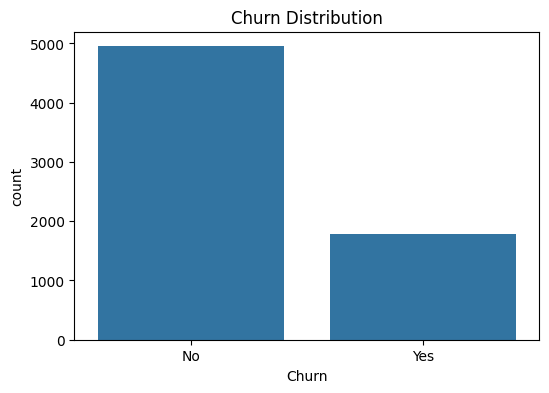

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET_COL, data=df_clean)
plt.title("Churn Distribution")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

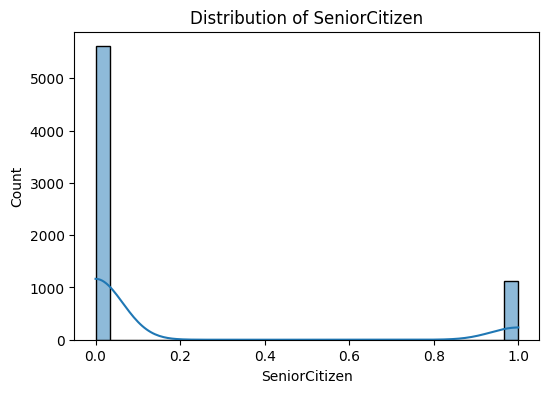

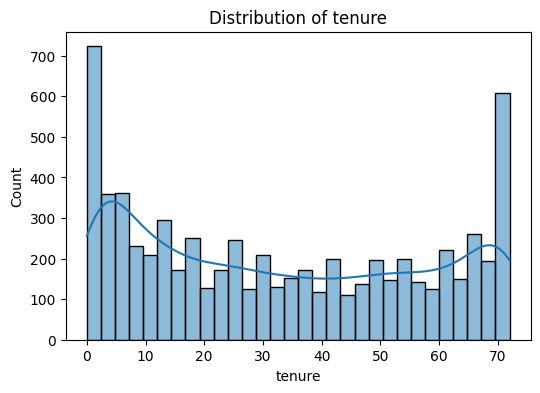

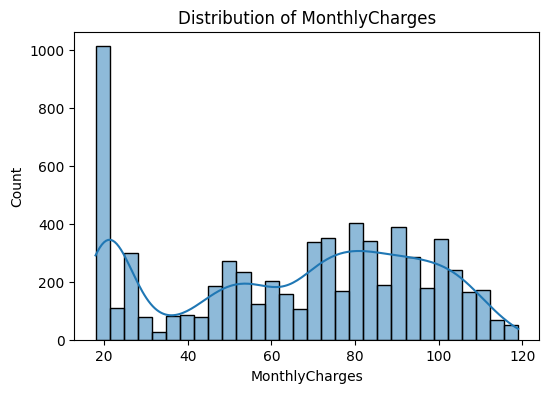

In [20]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_clean[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

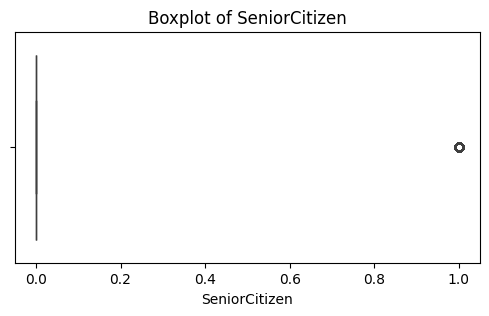

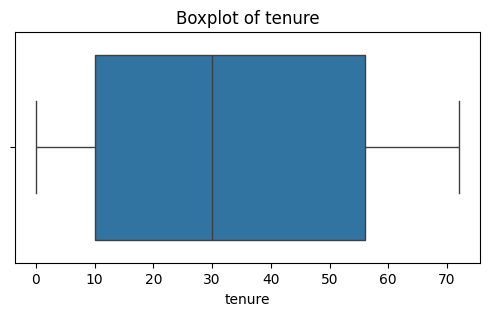

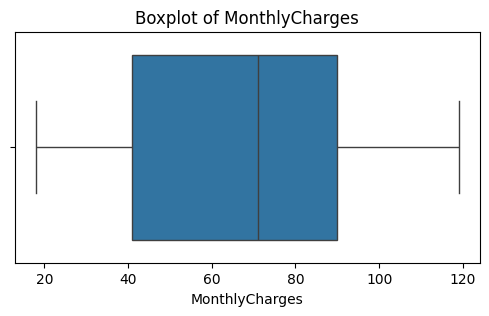

In [21]:
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

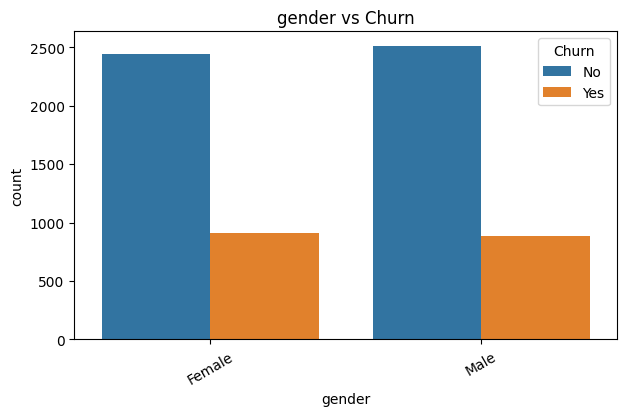

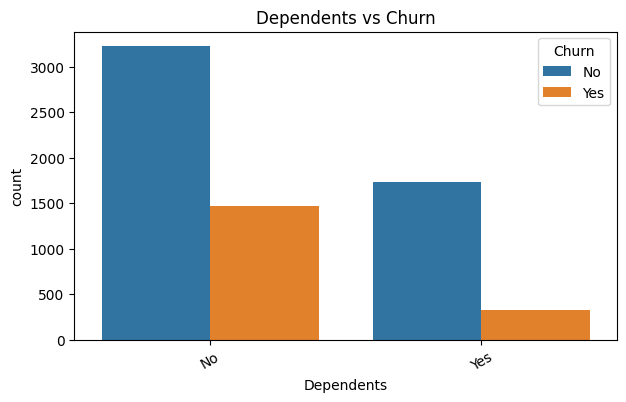

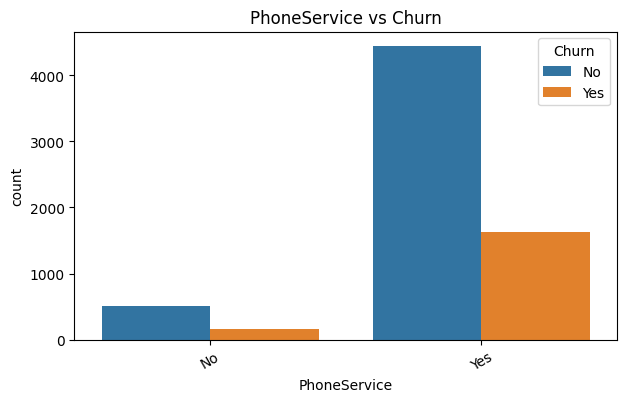

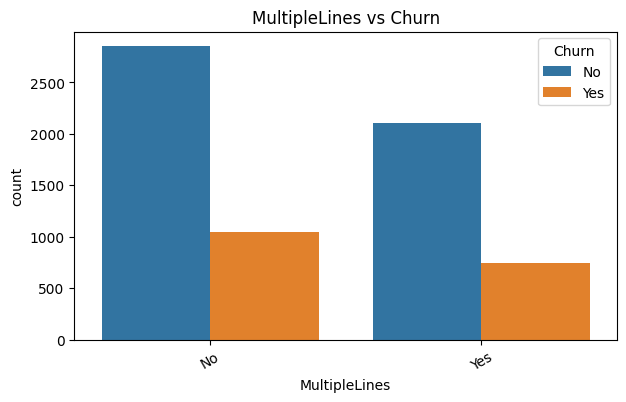

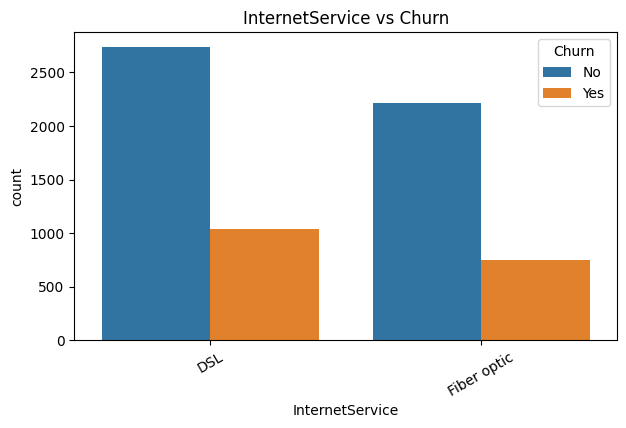

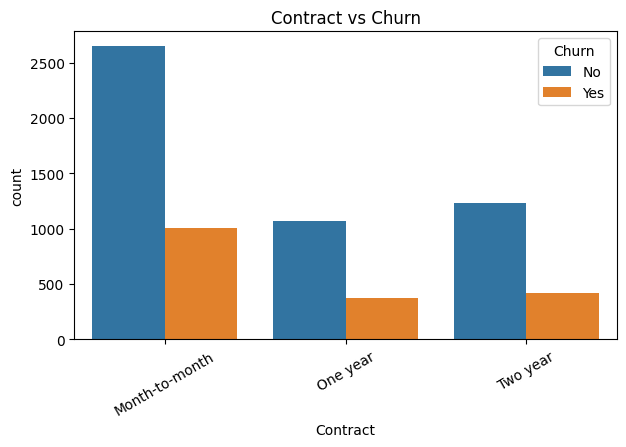

In [22]:
important_cat = [col for col in ["gender", "Dependents", "PhoneService", "MultipleLines", "InternetService", "Contract"] if col in df_clean.columns]

for col in important_cat:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df_clean, x=col, hue=TARGET_COL)
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=30)
    plt.legend(title="Churn", labels=["No", "Yes"])
    plt.show()

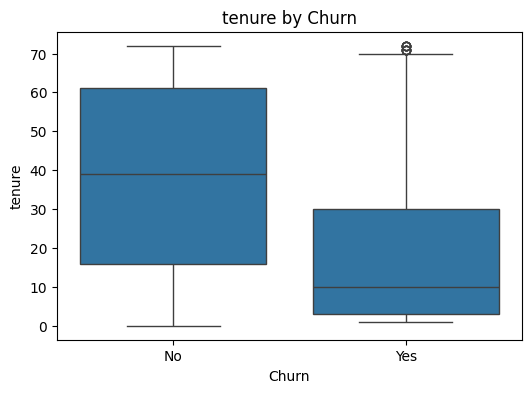

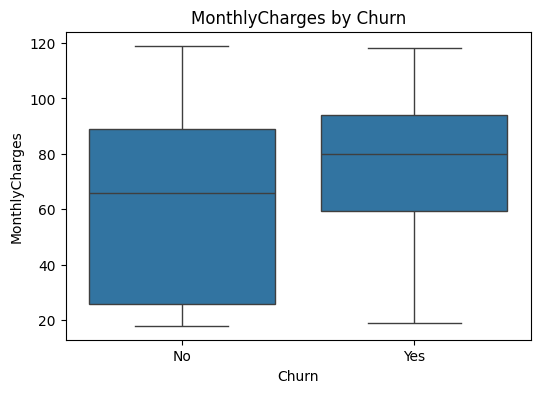

In [23]:
important_num = [col for col in ["tenure", "MonthlyCharges"] if col in df_clean.columns]

for col in important_num:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_clean, x=TARGET_COL, y=col)
    plt.title(f"{col} by Churn")
    plt.xticks([0, 1], ["No", "Yes"])
    plt.show()

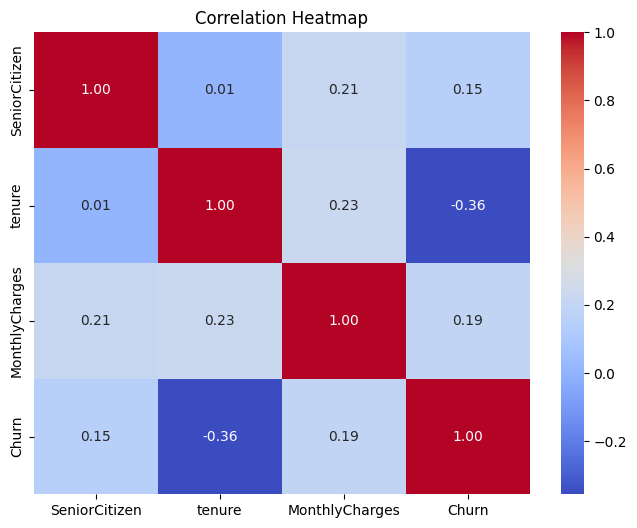

In [24]:
if numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_clean[numeric_cols + [TARGET_COL]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()

# K-Means clustering - Elbow and Silhouette Method

In [25]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = df_clean[["tenure", "MonthlyCharges"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

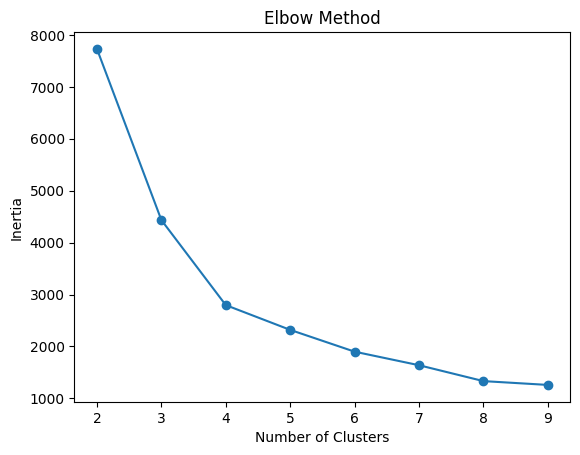

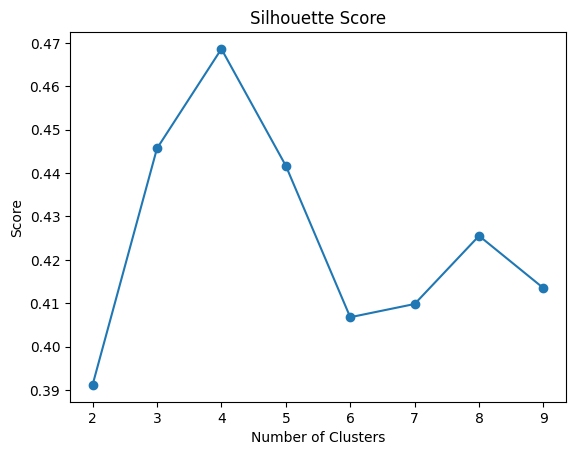

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

# Elbow plot
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Silhouette plot
plt.plot(K_range, silhouette, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.show()

CHOOSING K=4 based on above plots

# Train Final K-means Model

In [28]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df_clean["Cluster"] = kmeans.fit_predict(X_scaled)

In [30]:
X = df_clean[["tenure", "MonthlyCharges"]]

In [31]:
cluster_summary = df_clean.groupby("Cluster").agg({
    "tenure": "mean",
    "MonthlyCharges": "mean",
    "SeniorCitizen": "mean",
    "Churn": "mean"
}).round(2)

print(cluster_summary)

         tenure  MonthlyCharges  SeniorCitizen  Churn
Cluster                                              
0         11.34           33.76           0.08   0.25
1         14.93           81.66           0.24   0.49
2         58.58           93.04           0.22   0.16
3         54.17           34.67           0.08   0.05


# Clusters Visualisation

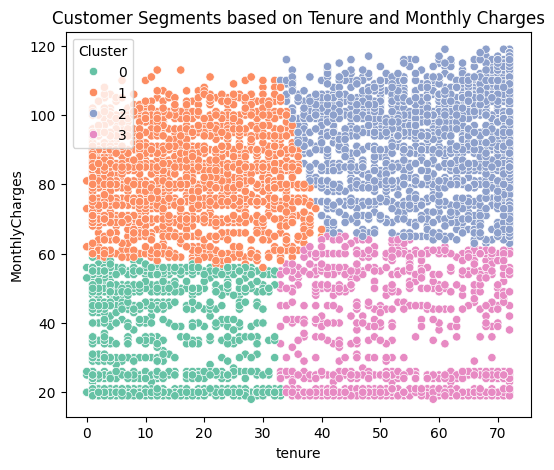

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.scatterplot(
    x=df_clean["tenure"],
    y=df_clean["MonthlyCharges"],
    hue=df_clean["Cluster"],
    palette="Set2"
)
plt.title("Customer Segments based on Tenure and Monthly Charges")
plt.show()

The clustering results indicate four customer segments with varying degrees of separation. While some clusters are clearly distinguishable, others exhibit overlap, suggesting shared characteristics among customers.

In [33]:
cluster_labels = {
    0: "New High Spenders",
    1: "Loyal Customers",
    2: "Low Value New Customers",
    3: "High Value Loyal Customers"
}

df_clean["Cluster_Label"] = df_clean["Cluster"].map(cluster_labels)

df_clean[["Cluster", "Cluster_Label"]].head()

,Cluster,Cluster_Label
0,0,New High Spenders
1,3,High Value Loyal Customers
2,3,High Value Loyal Customers
3,1,Loyal Customers
4,3,High Value Loyal Customers


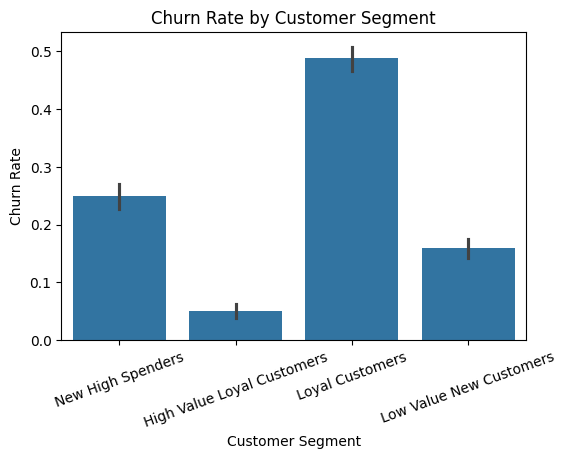

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(x="Cluster_Label", y="Churn", data=df_clean)

plt.title("Churn Rate by Customer Segment")
plt.ylabel("Churn Rate")
plt.xlabel("Customer Segment")
plt.xticks(rotation=20)
plt.show()

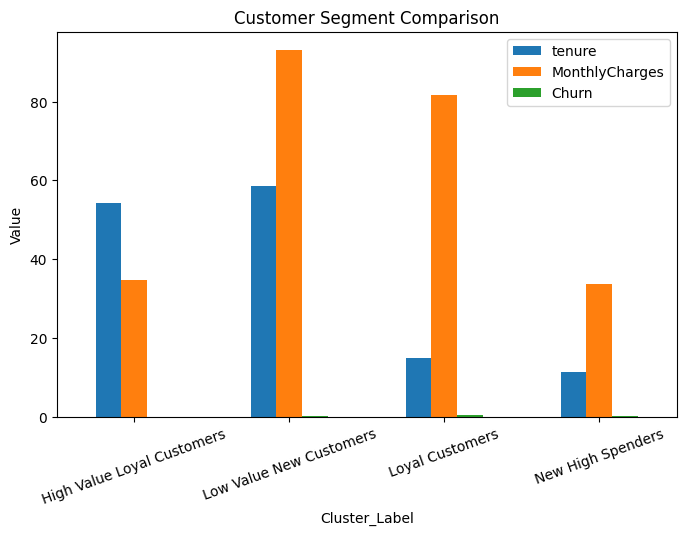

In [35]:
cluster_summary = df_clean.groupby("Cluster_Label").agg({
    "tenure": "mean",
    "MonthlyCharges": "mean",
    "Churn": "mean"
}).reset_index()

cluster_summary.plot(x="Cluster_Label", kind="bar", figsize=(8,5))
plt.title("Customer Segment Comparison")
plt.ylabel("Value")
plt.xticks(rotation=20)
plt.show()

Labeling Visualisation

In [36]:
cluster_labels = {
    0: "High Risk",
    1: "Loyal",
    2: "Price Sensitive",
    3: "Low Engagement"
}

df_clean["Cluster_Label"] = df_clean["Cluster"].map(cluster_labels)

In [37]:
print(cluster_labels)

{0: 'High Risk', 1: 'Loyal', 2: 'Price Sensitive', 3: 'Low Engagement'}
